# 06 -- Network Analysis

## Research Question
Which countries are structurally central in global trade -- not just big traders?

## Data
UN Comtrade bilateral exports, 2016 and 2023, 57-country network (US/India excluded, see `docs/LIMITATIONS.md`). PUBLIC.

## Method
NetworkX directed graph; betweenness centrality, eigenvector centrality, and PageRank computed for both years, compared. See `python/networks/trade_network.py`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
import sys, os
sys.path.insert(0, os.path.abspath('../python/visualisation'))
pd.set_option('display.max_columns', 20)

In [2]:
pagerank_change = pd.read_csv('../data/processed/trade_network_pagerank_change.csv')
print("Biggest network-importance gainers, 2016->2023 (PageRank):")
print(pagerank_change.sort_values('pagerank_change', ascending=False).head(6)[['Country','2016','2023','pagerank_change_pct']].round(4).to_string(index=False))
print("\nBiggest losers:")
print(pagerank_change.sort_values('pagerank_change').head(6)[['Country','2016','2023','pagerank_change_pct']].round(4).to_string(index=False))

Biggest network-importance gainers, 2016->2023 (PageRank):
             Country   2016   2023  pagerank_change_pct
United Arab Emirates 0.0268 0.0346              29.1509
               China 0.1235 0.1299               5.2240
              Poland 0.0168 0.0210              25.2071
             Turkiye 0.0190 0.0228              19.8987
        Saudi Arabia 0.0153 0.0189              23.4599
            Viet Nam 0.0194 0.0224              15.9134

Biggest losers:
             Country   2016   2023  pagerank_change_pct
      United Kingdom 0.0527 0.0390             -25.8993
Hong Kong SAR, China 0.0517 0.0406             -21.4178
           Singapore 0.0322 0.0237             -26.2192
               Japan 0.0448 0.0371             -17.1417
             Germany 0.0751 0.0707              -5.7744
  Iran, Islamic Rep. 0.0100 0.0059             -41.0191


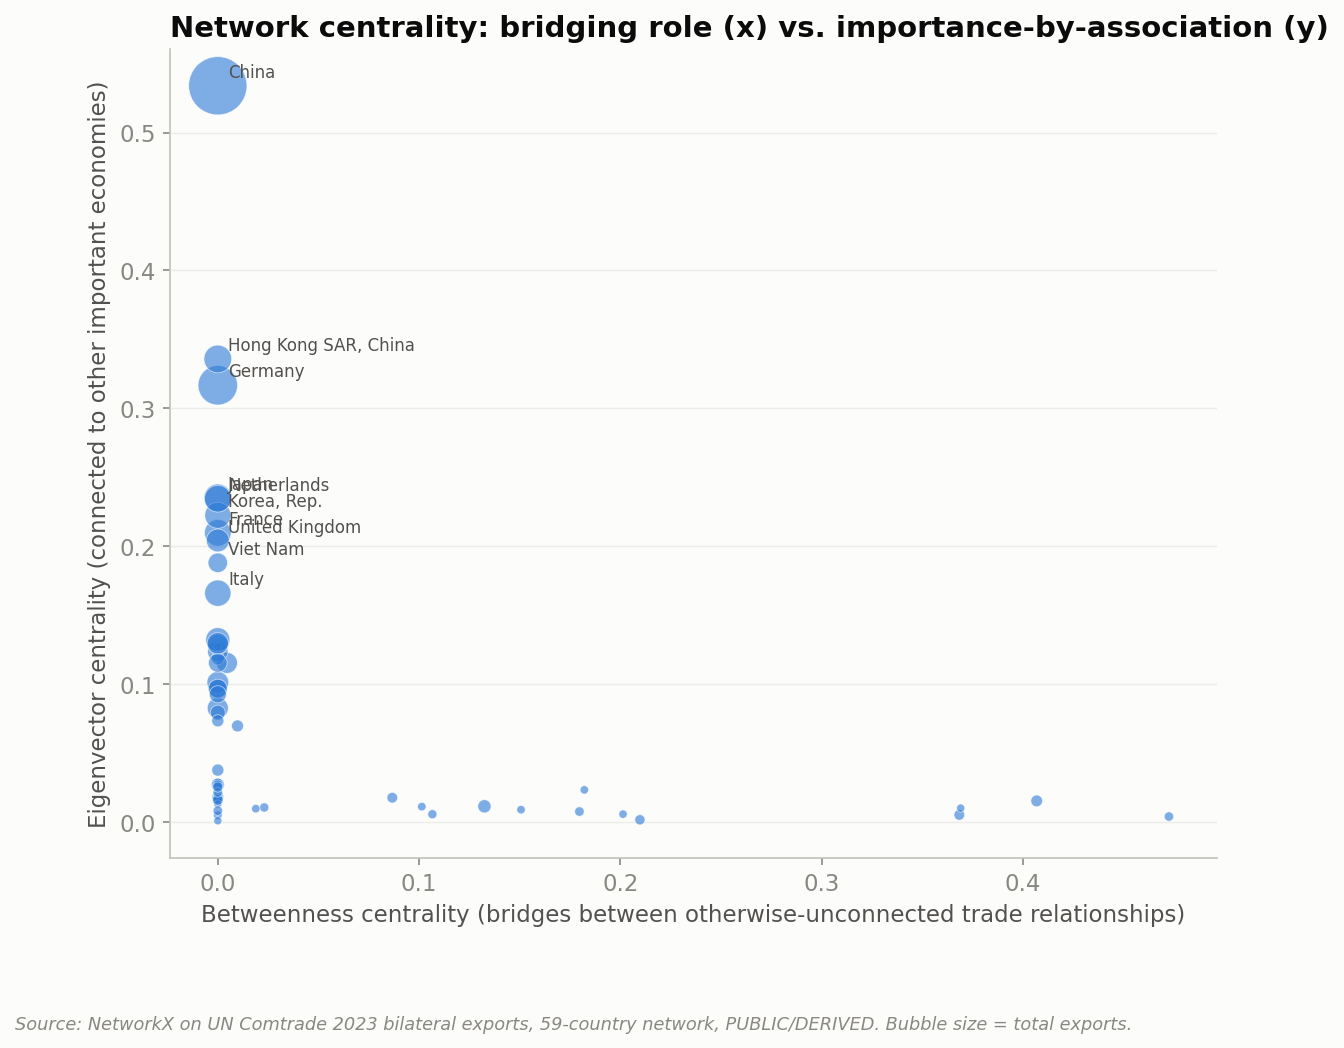

In [3]:
display(Image('../outputs/figures/11_network_centrality.png', width=750))

## Finding

The UAE gained the most network importance of any economy 2016-\>2023 (+29% PageRank), followed by China, Poland, Turkiye, Saudi Arabia, and Vietnam -- a real, data-driven signature of Gulf diversification and "China+1" manufacturing shifts, not an assumption read into the data. The UK, Hong Kong, Singapore, and Japan lost the most network importance over the same window, plausibly linked to Brexit, mainland China's relative port/manufacturing growth, and Japan's well-documented slow-growth trajectory respectively -- though this project's network data alone cannot establish causation for any of these, only the structural shift itself.

## Limitation

Two time points only (2016, 2023), and the US/India exclusion means their true centrality (plausibly very high, given their trade volumes) cannot be computed from this specific data source.

## Next Step

Notebook 07 combines everything into a formal risk index and produces a validated forecast for Malaysia.